# Phan tich dataCleand.csv

Notebook nay doc file du lieu da lam sach va ve bieu do doanh thu, loi nhuan theo danh muc san pham.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Doc file CSV
df = pd.read_csv(
    'dataCleand.csv',
    encoding='utf-8-sig',
    parse_dates=['Order Date', 'Ship Date']
)

print(f'So dong: {df.shape[0]:,}')
print(f'So cot: {df.shape[1]}')
df.head()

So dong: 9,994
So cot: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


,Category,Doanh_thu,Loi_nhuan
2,Technology,"$836,154","$145,455"
0,Furniture,"$742,000","$18,451"
1,Office Supplies,"$719,047","$122,491"


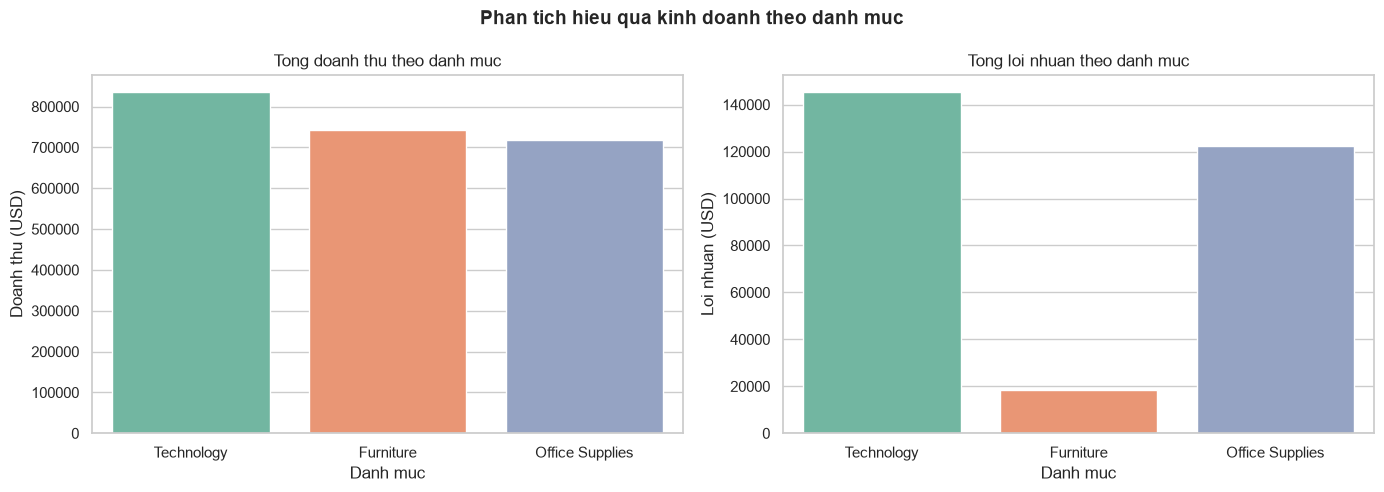

In [2]:
# Tong hop doanh thu va loi nhuan theo danh muc
category_summary = (df.groupby('Category', as_index=False)
                    .agg(Doanh_thu=('Sales', 'sum'), Loi_nhuan=('Profit', 'sum'))
                    .sort_values('Doanh_thu', ascending=False))

display(category_summary.style.format({'Doanh_thu': '${:,.0f}', 'Loi_nhuan': '${:,.0f}'}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('Set2', n_colors=len(category_summary))

sns.barplot(data=category_summary, x='Category', y='Doanh_thu', hue='Category',
            palette=colors, legend=False, ax=axes[0])
axes[0].set_title('Tong doanh thu theo danh muc')
axes[0].set_xlabel('Danh muc')
axes[0].set_ylabel('Doanh thu (USD)')
axes[0].ticklabel_format(style='plain', axis='y')

sns.barplot(data=category_summary, x='Category', y='Loi_nhuan', hue='Category',
            palette=colors, legend=False, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Tong loi nhuan theo danh muc')
axes[1].set_xlabel('Danh muc')
axes[1].set_ylabel('Loi nhuan (USD)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.suptitle('Phan tich hieu qua kinh doanh theo danh muc', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()